In [ ]:
import os

target_folder = "CS6423_knowledge_distillation_project" 
path = os.path.join(os.getcwd(), target_folder)

if not os.getgetcwd().endswith(target_folder):
    os.chdir(path)

# should match the folder you cloned into
print(f"Current working directory: {os.getcwd()}")

The first two cells here are for downloading the pretrained radimage net weights. Try option 1 first and if that doesn't work then try option 2

The reason to prefer option 1 is that option 2 can create some git 'weirdness' by nesting a git repo inside the main git repo

In [ ]:
# Option 1

from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="convergedmachine/RadImagenet",
    local_dir="RadImageNet_weights",
    local_dir_use_symlinks=False  # Ensures actual files are copied, not just links
)

In [ ]:
# Option 2

# this only works if git lfs is installed, if not it will download the pointers instead of the actual files
!git clone https://huggingface.co/convergedmachine/RadImagenet RadImageNet_weights

fatal: destination path 'RadImageNet_weights' already exists and is not an empty directory.


The next cell is for downloading the pretrained models from fiabar/cs6423_model_repo

In [ ]:
from huggingface_hub import snapshot_download, login
import os

login("hf_your_token_here")

snapshot_download(
    repo_id="kd-proj-cs6423/cs6423_model_repo",
    repo_type="model",
    local_dir=os.path.join(os.getcwd(), 'trained_models/')
)


c:\Users\fiach\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 17 files: 100%|██████████| 17/17 [00:24<00:00,  1.43s/it]


'C:\\Users\\fiach\\Documents\\Code\\msc\\scalable\\CS6423_knowledge_distillation_project\\trained_models'

# WARNING!!!

The rest of this notebook just shows how a particular model was loaded and trained as an exploration. If you want to train a model then follow `radimage_train_example.ipynb`. If you want to evaluate a model then follow `radimage_evaluate_example.ipynb`

In [1]:
import torch
import torch.nn as nn
from torchvision import models
import argparse
from collections import OrderedDict

checkpoint_path = "RadImageNet_weights/resnet50.pth"

model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, 165)
fc_num_ftrs = model.fc.in_features

# capture means to verify weight loading
backbone_mean_before = model.conv1.weight.data.mean().item()
head_mean_before = model.fc.weight.data.mean().item()

torch.serialization.add_safe_globals([argparse.Namespace])
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

state_dict = checkpoint['model']
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k.replace('_orig_mod.', '') 
    new_state_dict[name] = v

model.load_state_dict(new_state_dict, strict=True)

backbone_mean_after = model.conv1.weight.data.mean().item()
head_mean_after = model.fc.weight.data.mean().item()

# if non zero then weights loaded successfully
print(f"Backbone (conv1) Mean Diff: {backbone_mean_after - backbone_mean_before:.8f}")
print(f"Head (fc) Mean Diff:       {head_mean_after - head_mean_before:.8f}")

Backbone (conv1) Mean Diff: 0.00020122
Head (fc) Mean Diff:       -0.00005563


In [2]:
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [3]:
dummy_input = torch.randn(1, 3, 224, 224)

model.eval()

with torch.no_grad():
    output = model(dummy_input)

probabilities = torch.nn.functional.softmax(output, dim=1)
top_prob, top_class = torch.max(probabilities, dim=1)

print("Randomised Input Analysis\n---------------------")
print(f"Output shape:       {output.shape}")
print(f"Top class index:    {top_class.item()}")
print(f"Confidence score:   {top_prob.item():.4f}")
print(f"Sum of all probs:   {torch.sum(probabilities).item():.1f}")

Randomised Input Analysis
---------------------
Output shape:       torch.Size([1, 165])
Top class index:    48
Confidence score:   0.9927
Sum of all probs:   1.0


In [7]:
from PIL import Image
from torchvision import transforms
import os
import pandas as pd

# no normalisation for this model
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

labels_df = pd.read_csv('data/labels.csv')
sample_row = labels_df.iloc[12]
sample_filename = sample_row['filename']
ground_truth = sample_row['label']

test_dir = "data/test_images"
sample_path = os.path.join(test_dir, sample_filename)

img = Image.open(sample_path).convert('RGB')
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0)

model.eval()

with torch.no_grad():
    output = model(input_batch)

probabilities = torch.nn.functional.softmax(output[0], dim=0)
top_prob, top_catid = torch.topk(probabilities, 1)

print(f"Results for {sample_filename}:")

transforms.ToPILImage()(input_batch[0].cpu()).save("debug_input.png")

print(f"\nGround Truth: {ground_truth}")
print(f"Predicted:    {top_catid.item()} with confidence {top_prob.item():.4f}")

Results for test_12.png:

Ground Truth: ankle_foot_normal
Predicted:    118 with confidence 0.4794


## The problem
We dont know what class 118 refers to so we cannot measure model accuracy

## The solution
Retrain a the final FC layer with our own classifier based on the dataset we have

In [18]:
df = pd.read_csv('data/labels.csv')
num_classes = len(df['label'].unique())
print(num_classes)
df.head()

61


,filename,pathology,modality,location,label
0,test_0.png,soft_tissue_fluid,mri,ankle foot,ankle_foot_soft_tissue_fluid
1,test_1.png,osseous_disruption,mri,ankle foot,ankle_foot_osseous_disruption
2,test_2.png,chondral_abnormality,mri,ankle foot,ankle_foot_chondral_abnormality
3,test_3.png,achilles_pathology_,mri,ankle foot,ankle_foot_achilles_pathology_
4,test_4.png,achilles_pathology_,mri,ankle foot,ankle_foot_achilles_pathology_


<Axes: title={'center': 'Class Distribution in Dataset'}, xlabel='label'>

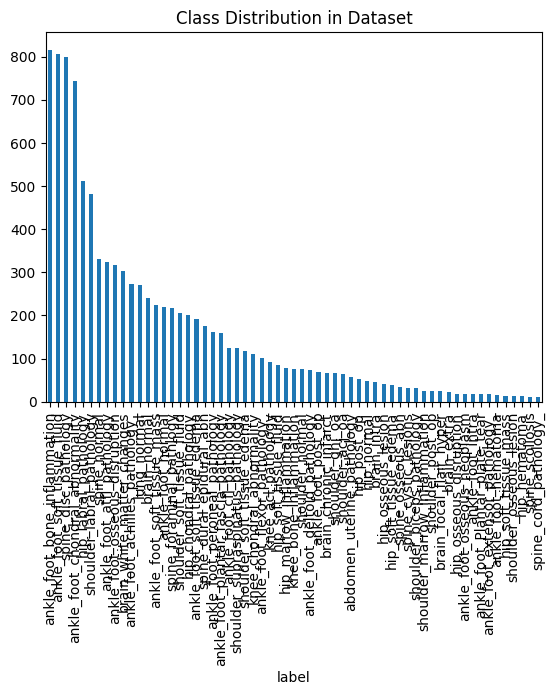

In [13]:
label_counts = df['label'].value_counts()
label_counts.plot(kind='bar', title='Class Distribution in Dataset')

In [14]:
print(label_counts.tail(10))

label
ankle_foot_osseous_neoplasm       18
ankle_foot_intra                  17
ankle_foot_Plantar_plate_tear     17
ankle_foot_extensor_pathology_    17
ankle_foot_hematoma               16
hip_soft_tissue_mass              14
shoulder_osseous_lesion           14
hip_hematoma                      13
spine_scoliosis                   12
spine_cord_pathology_             11
Name: count, dtype: int64


In [15]:
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

In [16]:
# create new layer
model.fc = nn.Sequential(
    nn.Dropout(p=0.5), # due to small dataset
    nn.Linear(fc_num_ftrs, num_classes)
)

# freeze ALL parameters in the model
for param in model.parameters():
    param.requires_grad = False

# unfreeze ONLY the final classification head
for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split

class RadiologyDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform
        
        # map string labels to numbers (0-121)
        self.labels = self.df['label'].astype('category').cat.codes.values
        self.class_names = self.df['label'].astype('category').cat.categories

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=43
)

train_set = RadiologyDataset(train_df, image_dir="data/test_images", transform=train_transforms)
test_set = RadiologyDataset(test_df, image_dir="data/test_images", transform=preprocess)

print(len(train_set))
print(len(test_set))

7948
1988


In [ ]:
counts = df['label'].value_counts().sort_index().values
weights = 1.0 / torch.tensor(counts, dtype=torch.float)
weights = weights / weights.sum() * len(counts)
weights = weights.to(device)

all_sample_labels = train_set.labels
sample_weights = [weights[l] for l in all_sample_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

train_loader = DataLoader(
    train_set, 
    batch_size=32, 
    sampler=sampler
)

test_loader = DataLoader(
    test_set,
    batch_size=32,
    shuffle=False
)

The following shows how to run an example training. If you want to run training than follow train_example.ipynb to use the helper classes

In [ ]:
from tqdm import tqdm
import torch.optim as optim
from sklearn.metrics import f1_score

def train_model(model, train_loader, test_loader, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(weight=weights.to(device))
    
    for epoch in range(epochs):
        model.train()
        for m in model.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()

        running_loss = 0.0
        all_preds = []
        all_labels = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch")
        
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix(loss=loss.item())

        # training metrics
        epoch_loss = running_loss / len(train_loader)
        epoch_f1 = f1_score(all_labels, all_preds, average='macro')
        
        # validation metrics
        model.eval()
        val_running_loss = 0.0
        val_preds = []
        val_labels = []
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
        
        val_loss = val_running_loss / len(test_loader)
        val_f1 = f1_score(val_labels, val_preds, average='macro')
        
        # End of epoch summary
        torch.save(model.state_dict(), 'radimagenet_vqa_finetuned.pth')
        print("Model saved safely.")
        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {epoch_loss:.4f} | Train F1: {epoch_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}\n")

In [155]:
train_model(model, train_loader, test_loader, epochs=10)

Epoch 1/10: 100%|██████████| 225/225 [10:31<00:00,  2.81s/batch, loss=0.594]


Model saved safely.

Epoch 1
Train Loss: 1.7898 | Train F1: 0.4582
Val Loss: 1.1010 | Val F1: 0.5553



Epoch 2/10: 100%|██████████| 225/225 [10:17<00:00,  2.74s/batch, loss=0.282]


Model saved safely.

Epoch 2
Train Loss: 0.5173 | Train F1: 0.7409
Val Loss: 0.6948 | Val F1: 0.6634



Epoch 3/10: 100%|██████████| 225/225 [10:26<00:00,  2.79s/batch, loss=0.324]


...

Model saved safely.

Epoch 8
Train Loss: 0.1162 | Train F1: 0.9164
Val Loss: 0.2333 | Val F1: 0.8696



Epoch 9/10: 100%|██████████| 225/225 [10:22<00:00,  2.77s/batch, loss=0.132] 


Model saved safely.

Epoch 9
Train Loss: 0.1058 | Train F1: 0.9197
Val Loss: 0.2222 | Val F1: 0.8672



Epoch 10/10: 100%|██████████| 225/225 [10:22<00:00,  2.77s/batch, loss=0.21]  


Model saved safely.

Epoch 10
Train Loss: 0.0983 | Train F1: 0.9309
Val Loss: 0.2010 | Val F1: 0.8795

